In [8]:
import matplotlib.pyplot as plt 
import json
from glob import glob

from collections import defaultdict
import os
import numpy as np

import pandas as pd

import seaborn as sns

cpu='Intel'
dataset_names=[
    "adult",
    # "electricity",
    # "forest_cover",
    # "hyperplane_high_gradual_drift",
    # "insects",
    # "movingRBF",
    # "moving_squares",
    # "new_airlines",
    # "rialto",
    # "river_aggrawal",
    # "river_anomalysine",
    # "river_hyperlane_2",
    "river_hyperlane",
    # "river_led",
    # "river_led_default_drift",
    # "river_mixed",
    # "river_randomRBF_2",
    # "river_randomRBF",
    # "river_randomRBF_drift",
    # "river_randomTree_2",
    # "river_randomTree",
    # "river_SEA_2",
    "river_SEA",
    # "river_SINE",
    # "river_STAGGER",
    # "river_Waveform_2",
    # "river_Waveform",
    # "sea_high_abrupt_drift",
    # "sea_high_mixed_drift",
    "shuttle",
    # "skmul_aggrawal",
    # "skmul_anomalysine_2",
    # "skmul_anomalysine",
    # "skmul_hyperlane",
    # "skmul_ledgenerator",
    # "skmul_ledgenerator_default_drift",
    # "skmul_randomRBF_default_drift",
    # "skmul_randomRBF_gradual",
    # "skmul_randomTree_2",
    "skmul_randomTree",
    # "skmul_SEA_2",
    # "skmul_SEA",
    # "skmul_Sine",
    # "skmul_STAGGER_2",
    # "skmul_STAGGER",
    # "skmul_Waveform",
    # "synth_agrawal",
    # "synth_RandomRBFDrift",
    # "vehicle_sensIT",
    "weather"
]



model_names=('HATC','ARFC','AutoClass','AutoStreamML','SRPC', 'EvoAutoML','OnlineAutoML','ChaCha')


dataset_by_model={}
for dataset in dataset_names:
    dataset_by_model[dataset]={}

for model in model_names:
    for dataset in dataset_names:
        dataset_by_model[dataset][model]=glob(f'./experiment-results_{cpu}/{model}/{model}_{dataset}*')

In [9]:
!free -m

               total        used        free      shared  buff/cache   available
Mem:           19843        9260        1238         261        9534       10582
Swap:          19842        7919       11923


In [10]:
import gc
import warnings
warnings.filterwarnings('ignore')
gc.collect()

483

In [11]:
import matplotlib.pyplot as plt

print("Default font size:", plt.rcParams["font.size"])  # 10 by default
print("Default axis labels size:", plt.rcParams["axes.labelsize"])  # 12
print("Default title size:", plt.rcParams["axes.titlesize"])  # 14
print("Default xticks/yticks size:", plt.rcParams["xtick.labelsize"])  # 10
print("Default legend size:", plt.rcParams["legend.fontsize"])  # 10


Default font size: 10.0
Default axis labels size: medium
Default title size: large
Default xticks/yticks size: medium
Default legend size: medium


In [12]:
# import seaborn as sns
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import multiprocessing
import re
from collections import defaultdict
import gc

def downsample(data, window_size):
    """Averages every `window_size` instances."""
    n = len(data) // window_size * window_size  # Trim to multiple of window_size
    return data[:n].reshape(-1, window_size).mean(axis=1)

In [13]:

def convert_snake_case_to_title_case(snake_case_string):
    """
    Converts a snake_case string to Title Case.

    Args:
        snake_case_string: The input string in snake_case.

    Returns:
        The string converted to Title Case.
    """
    if snake_case_string=='movingRBF':#1
        return 'Moving RBF'
    elif snake_case_string== 'synth_agrawal':#2
        return 'Agrawal'
    elif snake_case_string== 'vehicle_sensIT':#3
        return 'Vehicle SensIT'
    elif snake_case_string== 'sea_high_abrupt_drift':#4
        return 'SEA High Abrupt Drift'
    elif snake_case_string== 'sea_high_mixed_drift':#5
        return 'SEA High Gradual Drift'
    elif snake_case_string== 'synth_RandomRBFDrift':#7
        return 'Random RBF'
    elif snake_case_string== 'hyperplane_high_gradual_drift':
        return 'Hyperlane Gradual Drift'
    else:
        words = snake_case_string.split('_')
        title_case_words = [word.capitalize() for word in words]
        return ' '.join(title_case_words)

In [14]:
default_config=True

model_names_for_stats=('AutoClass','AutoStreamML','EvoAutoML',"OnlineAutoML","SRPC","HATC","ARFC")

model_scores = {}
model_time = {}
model_energy = {}
model_kappa = {}
model_kappa_plus = {}

# Initialize the dictionaries to hold data for each model
for model in model_names_for_stats:
    model_scores[model] = []
    model_time[model] = []
    model_energy[model] = []
    model_kappa[model] = []
    model_kappa_plus[model] = []

for data_idx, data_name in enumerate(dataset_names):

    real_dataset = pd.read_csv(f'stream_datasets/{data_name}.csv')
    class_values = real_dataset['class']
    if len(class_values)>100000:
        window_size=10000
    else:
        window_size=1000
    
    threshold = int(len(class_values) - window_size)
    class_values = class_values[:threshold]



    for model in model_names_for_stats:

        
        for sample in dataset_by_model[data_name][model]:
            if default_config==True:
                if model == 'AutoClass':
                    if 'population_size_10_exploration_window_1000' not in sample:
                        continue
                if model == 'AutoStreamML':
                    if 'exploration_window_1000_ensemble_size_3_budget_10' not in sample:
                        continue
                if model == 'EvoAutoML':
                    if 'population_size_10_sampling_size_1_sampling_rate_1000' not in sample:
                        continue
                if model == 'SRPC' or model =='ARFC' or model=='HATC':
                    if 'nmodel_3' not in sample:
                        continue

            with open(sample) as f:
                data = json.load(f)



            energy_consumed = np.array(data['energy_consumed'])

            if len(energy_consumed) < threshold:
                continue


            energy_consumed = energy_consumed[:threshold]

            energy_consumed *= 3600000  # Convert to proper units



            down_energy_consumed = downsample(energy_consumed, window_size)




            model_energy[model] = np.concatenate([model_energy[model], down_energy_consumed])



### Framework to framework comparision

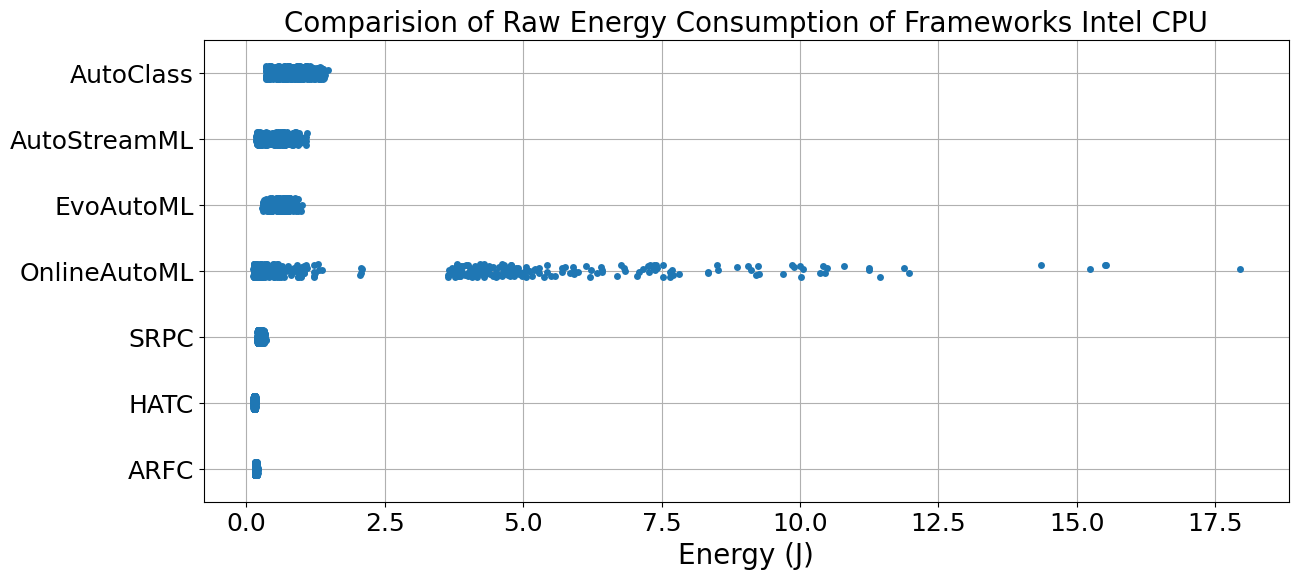

In [15]:
metrics = {
    'model_energy': model_energy
 }

# Loop over each metric
for metric_name, metric_data in metrics.items():
    # Flatten scores for all models
    all_scores = []
    model_labels = []

    for model, scores in metric_data.items():
        # flattened_scores = [score for sublist in scores for score in sublist]
        all_scores.append(scores)
        model_labels.append(model)

    # # Create a boxplot for the current metric
    plt.figure(figsize=(14, 6))
    # sns.boxplot(data=all_scores, showfliers=True)

        # Prepare data in long format
    x_vals = []
    y_labels = []

    for model, scores in metric_data.items():
        x_vals.extend(scores)
        y_labels.extend([model] * len(scores))

    # Scatter plot per model (horizontal)
    sns.stripplot(x=x_vals, y=y_labels, jitter=True)

    titles={
        'model_scores': 'Comparision of Prequential Accuracy of Frameworks',
        'model_time': 'Comparision of Inference Time of Frameworks',
        'model_energy': f'Comparision of Raw Energy Consumption of Frameworks {cpu} CPU',
        'model_kappa': 'Comparision of Kappa Statistic of Frameworks',
        'model_kappa_plus': 'Comparision of $Kappa^+$ Statistic of Frameworks'
    }
    y_labels={
        'model_scores': 'Accuracy',
        'model_time': 'Inference Time(ms)',
        'model_energy': 'Energy (J)',
        'model_kappa': 'k',
        'model_kappa_plus': '$k^+$'
    }
    

    # Add grid and increase font size
    plt.title(f'{titles.get(metric_name)}', fontsize=20)
    # plt.ylabel(y_labels.get(metric_name), fontsize=20)
    # plt.ylabel(metric_name)
    #plt.yscale('log')
    # plt.ylim(0,12)
    # plt.xticks(range(len(model_labels)), model_labels, fontsize=20,rotation=20)  # Increase font size for x-ticks
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)  # Increase font size for y-ticks
    plt.xlabel(y_labels.get(metric_name), fontsize=20)
    # plt.ylabel("Models", fontsize=20)
    plt.grid(True)

    # Show the plot for this metric
    plt.show()